# Importing  important  requirement 

In [2]:
import pandas as  pd
import  numpy as np
import  matplotlib as plt 
import  seaborn as sns

In [3]:
import requests
import  csv
import json
import os
import re

# Getting API

In [4]:

# ⚠️ Put your NEW API key here
API_KEY = "7c8eca4ce6msh5db3313e36dae02p1b8723jsndcd477ef3bb4"
headers = {
    "Content-Type": "application/json",
    "X-RapidAPI-Key": API_KEY,
    "X-RapidAPI-Host": "instagram120.p.rapidapi.com"
}

post_url = "https://instagram120.p.rapidapi.com/api/instagram/posts"

all_posts = []   # ✅ VERY IMPORTANT (define first)
max_id = ""

for _ in range(10):   # 10 pages (~100+ posts)
    payload = {
        "username": "indiancricketteam",
        "maxId": max_id
    }

    response = requests.post(post_url, json=payload, headers=headers)
    data = response.json()

    posts = data.get("result", {}).get("edges", [])
    all_posts.extend(posts)

    max_id = data.get("result", {}).get("page_info", {}).get("end_cursor", "")

    if not max_id:
        break

print("Total posts collected:", len(all_posts))
# -------------------------
# 2️⃣ Process Posts
# -------------------------

for post in posts:
    node = post.get("node", {})

    post_id = node.get("id")
    username = node.get("owner", {}).get("username", "")

    # 🔹 FIX: Proper caption extraction
    caption_data = node.get("caption", "")

    if isinstance(caption_data, dict):
        caption = caption_data.get("text", "")
    else:
        caption = caption_data or ""

    # 🔹 FIX: Proper comments extraction
    comment_count= node.get("comments_count", 0)

    if isinstance(comment_count, dict):
        comment_count = comment_count.get("count", 0)
    else:
        comment_count = comment_count or 0

    # 🔹 Extract Hashtags
    hashtags = re.findall(r"#\w+", caption)

    # 🔹 Extract Mentions
    mentions = re.findall(r"@\w+", caption)

    print("\n==============================")
    print("Post ID:", post_id)
    print("Username:", username)
    print("Caption:", caption)
    print("Hashtags:", hashtags)
    print("Mentions:", mentions)
    print("comments:", comment_count)

Total posts collected: 120

Post ID: 3827747288501184594_2091666763
Username: indiancricketteam
Caption: When the captain calls, you answer 👌

🎥 From comeback to World Cup impact, ft. Mohd. Siraj 😎 

#TeamIndia | #MenInBlue | #T20WorldCup | #INDvUSA | @mohammedsirajofficial
Hashtags: ['#TeamIndia', '#MenInBlue', '#T20WorldCup', '#INDvUSA']
Mentions: ['@mohammedsirajofficial']
comments: 0

Post ID: 3827433518691881452_2091666763
Username: indiancricketteam
Caption: Painting the ground with his masterful shot-making 🎨👏

One word for Captain Surya Kumar Yadav's match-winning knock? 👇

#TeamIndia | #MenInBlue | #T20WorldCup | #INDvUSA
Hashtags: ['#TeamIndia', '#MenInBlue', '#T20WorldCup', '#INDvUSA']
Mentions: []
comments: 0

Post ID: 3827430289933428701_2091666763
Username: indiancricketteam
Caption: A captain’s knock to start the campaign 🫡

For his match-winning 84* (49), Surya Kumar Yadav is the Player of the Match as #TeamIndia begin the #T20WorldCup with a win! 👏

#MenInBlue | #INDvU

Save Data in  CSV form

In [5]:
with open("instagram_dataset.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow([
        "post_id",
        "username",
        "caption",
        "hashtags",
        "mentions",
        "likes",
        "comment_count"
    ])

    for post in all_posts:   # ✅ IMPORTANT CHANGE
        node = post.get("node", {})

        post_id = node.get("id", "")
        username = node.get("owner", {}).get("username", "")
        likes = node.get("like_count", 0)
        comment_count = node.get("comments_count", 0)

        caption_data = node.get("caption", "")

        if isinstance(caption_data, dict):
            caption = caption_data.get("text", "")
        else:
            caption = caption_data or ""

        hashtags = re.findall(r"#\w+", caption)
        mentions = re.findall(r"@\w+", caption)

        writer.writerow([
            post_id,
            username,
            caption,
            ", ".join(hashtags),
            ", ".join(mentions),
            likes,
            comment_count
        ])

print("Dataset created successfully ✅")
print("Total rows written:", len(all_posts))


Dataset created successfully ✅
Total rows written: 120


In [6]:
df=pd.read_csv("instagram_dataset.csv")
df

,post_id,username,caption,hashtags,mentions,likes,comment_count
0,3757158876308143282_2091666763,indiancricketteam,𝐂.𝐇.𝐀.𝐌.𝐏.𝐈.𝐎.𝐍.𝐒 🏆\n\nCongratulations to #Tea...,"#TeamIndia, #WomenInBlue, #CWC25, #Final, #INDvSA",NaN,4736442,0
1,3584595824401203523_2091666763,indiancricketteam,𝗖. 𝗛. 𝗔. 𝗠. 𝗣. 𝗜. 𝗢. 𝗡. 𝗦! 🏆 🏆 🏆\n\nThe Rohit ...,"#TeamIndia, #ChampionsTrophy, #INDvNZ, #Final",NaN,6090099,0
2,3833711483344354403_2091666763,indiancricketteam,"Sixes, crucial catches, BIG IMPACT 😎\n\n🎥 Pres...","#TeamIndia, #T20WorldCup, #MenInBlue",NaN,130993,0
3,3833606553107385019_2091666763,indiancricketteam,A tale from one four-wicket haul to another ❤️...,"#TeamIndia, #AUSvIND",NaN,77500,0
4,3833545107770140826_2091666763,indiancricketteam,The Unfolding\n\nRaw. Real. Colombo.\n\n#TeamI...,"#TeamIndia, #T20WorldCup, #MenInBlue",NaN,233200,0
...,...,...,...,...,...,...,...
115,3827404635674336850_2091666763,indiancricketteam,There's another breakthrough ☝️\n\n🔝 work by I...,"#TeamIndia, #MenInBlue, #T20WorldCup, #INDvUSA",NaN,175115,0
116,3827391828803213350_376525195,icc,Arshdeep Singh gave India an early breakthroug...,#T20WorldCup,NaN,209768,0
117,3827388979922920451_376525195,icc,Rohit Sharma. Wankhede. #T20WorldCup Trophy in...,#T20WorldCup,NaN,2217703,0
118,3827389515141316940_2091666763,indiancricketteam,A successful powerplay 🙌\n\n#TeamIndia pick 3⃣...,"#TeamIndia, #MenInBlue, #T20WorldCup, #INDvUSA",NaN,273767,0


In [7]:
df.sample(5)

,post_id,username,caption,hashtags,mentions,likes,comment_count
27,3833056420661378190_2091666763,indiancricketteam,4⃣ Overs\n2⃣2⃣ Runs\n4⃣ Wickets 🔥\n\nArundhati...,"#TeamIndia, #AUSvIND",NaN,84447,0
116,3827391828803213350_376525195,icc,Arshdeep Singh gave India an early breakthroug...,#T20WorldCup,NaN,209768,0
100,3828544022366077565_2091666763,indiancricketteam,Making his debut at an ICC event after 4⃣0⃣ ye...,#T20WorldCup,NaN,181802,0
111,3827428604007789663_2091666763,indiancricketteam,A comprehensive victory ✌️\n\n#TeamIndia are o...,"#TeamIndia, #T20WorldCup, #INDvUSA, #MenInBlue",NaN,391350,0
28,3833048088819137205_2091666763,indiancricketteam,The match has been called off due to rain.\n\n...,"#TeamIndia, #AUSvIND",NaN,87983,0


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   post_id        120 non-null    object
 1   username       120 non-null    object
 2   caption        120 non-null    object
 3   hashtags       119 non-null    object
 4   mentions       10 non-null     object
 5   likes          120 non-null    int64 
 6   comment_count  120 non-null    int64 
dtypes: int64(2), object(5)
memory usage: 6.7+ KB


In [9]:
df.isnull().sum()

post_id            0
username           0
caption            0
hashtags           1
mentions         110
likes              0
comment_count      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,likes,comment_count
count,1.200000e+02,120.0
mean,4.657302e+05,0.0
std,8.135477e+05,0.0
min,6.136300e+04,0.0
25%,1.307258e+05,0.0
50%,2.257195e+05,0.0
75%,3.907185e+05,0.0
max,6.090099e+06,0.0


Data Preprocessing

In [12]:
df.drop(columns=['post_id','username','mentions'], inplace=True)


In [13]:
df['hashtags'] = df['hashtags'].fillna('')


In [14]:
df

,caption,hashtags,likes,comment_count
0,𝐂.𝐇.𝐀.𝐌.𝐏.𝐈.𝐎.𝐍.𝐒 🏆\n\nCongratulations to #Tea...,"#TeamIndia, #WomenInBlue, #CWC25, #Final, #INDvSA",4736442,0
1,𝗖. 𝗛. 𝗔. 𝗠. 𝗣. 𝗜. 𝗢. 𝗡. 𝗦! 🏆 🏆 🏆\n\nThe Rohit ...,"#TeamIndia, #ChampionsTrophy, #INDvNZ, #Final",6090099,0
2,"Sixes, crucial catches, BIG IMPACT 😎\n\n🎥 Pres...","#TeamIndia, #T20WorldCup, #MenInBlue",130993,0
3,A tale from one four-wicket haul to another ❤️...,"#TeamIndia, #AUSvIND",77500,0
4,The Unfolding\n\nRaw. Real. Colombo.\n\n#TeamI...,"#TeamIndia, #T20WorldCup, #MenInBlue",233200,0
...,...,...,...,...
115,There's another breakthrough ☝️\n\n🔝 work by I...,"#TeamIndia, #MenInBlue, #T20WorldCup, #INDvUSA",175115,0
116,Arshdeep Singh gave India an early breakthroug...,#T20WorldCup,209768,0
117,Rohit Sharma. Wankhede. #T20WorldCup Trophy in...,#T20WorldCup,2217703,0
118,A successful powerplay 🙌\n\n#TeamIndia pick 3⃣...,"#TeamIndia, #MenInBlue, #T20WorldCup, #INDvUSA",273767,0


Text preprocessing  :-- Remove  emojis  ,  links, etc

In [15]:
!pip install nltk emoji


In [16]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KITTU\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KITTU\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [17]:
import pandas as pd
import re
import emoji
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# load dataset
df = pd.read_csv("instagram_dataset.csv")

# stopwords + stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):

    if pd.isna(text):
        return ""

    # 1 lowercase
    text = text.lower()

    # 2 remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3 remove mentions
    text = re.sub(r'@\w+', '', text)

    # 4 remove hashtags symbol only (#car -> car)
    text = re.sub(r'#', '', text)

    # 5 remove emojis
    text = emoji.replace_emoji(text, replace='')

    # 6 remove numbers
    text = re.sub(r'\d+', '', text)

    # 7 remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # 8 tokenization
    words = text.split()

    # 9 remove stopwords
    words = [w for w in words if w not in stop_words]

    # 10 stemming
    words = [stemmer.stem(w) for w in words]

    return " ".join(words)

# apply to captions
df['clean_caption'] = df['caption'].apply(preprocess)

# save cleaned data
df.to_csv("cleaned_dataset.csv", index=False)

print("Preprocessing done ✅")


Preprocessing done ✅


TF-IDF (Term Frequency – Inverse Document Frequency)

In [18]:

from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("cleaned_dataset.csv")

# input text    
X_text = df['clean_caption']

# convert text to numbers
vectorizer = TfidfVectorizer(max_features=4000)

X = vectorizer.fit_transform(X_text)

print(X.shape)


(120, 619)


Quick Automatic Labeling

In [81]:
bad_words = [
'hate','kill','stupid','idiot','ugly','trash','loser','fool','dumb',
'shut','abuse','worst','nonsense','pathetic','worthless','annoying',
'terrible','garbage','disgusting','moron','jerk','screw','hell',
'get lost','go away','nobody likes you','you suck','stfu','wtf'
]

def create_label(text):
    words = re.findall(r'\b\w+\b', str(text))
    for word in words:
        if word in bad_words:
            return 1
    return 0

df['label'] = df['clean_caption'].apply(create_label)

In [82]:
df['label'].value_counts()


label
0    131
1     11
Name: count, dtype: int64

In [83]:
toxic_samples = [
"go to hell",
"get lost idiot",
"nobody likes you",
"you are pathetic",
"you suck man",
"what a garbage post",
"this is disgusting",
"worst thing ever",
"shut up please",
"annoying person",
"you are worthless",
"stop talking nonsense",
"terrible content",
"this is horrible",
"such a dumb idea",
"you make no sense",
"ridiculous post",
"this is crap",
"stupid behavior",
"i cant stand you"
]

toxic_df = pd.DataFrame({
    "clean_caption": toxic_samples,
    "label": [1]*len(toxic_samples)
})


In [84]:
safe_samples = [
    "i love you",
    "thank you so much",
    "you are my friend",
    "you are amazing",
    "happy birthday to you",
    "you did a great job",
    "you are very kind",
    "love you bro",
    "i appreciate you",
    "you are awesome"
]

safe_df = pd.DataFrame({
    "clean_caption": safe_samples,
    "label": [0]*len(safe_samples)
})


In [85]:
df = pd.concat([df[['clean_caption','label']], toxic_df, safe_df], ignore_index=True)

df['label'].value_counts()


label
0    141
1     31
Name: count, dtype: int64

In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=4000)
X = vectorizer.fit_transform(df['clean_caption'])

y = df['label']


Model Training

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=200)

In [88]:
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)


In [89]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred_lr))


Accuracy: 0.8


In [90]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_lr)
print(cm)


[[28  0]
 [ 7  0]]


In [91]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))


Naive Bayes Accuracy: 0.8285714285714286


In [92]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))


SVM Accuracy: 0.8285714285714286


In [93]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))


Random Forest Accuracy: 0.8571428571428571


In [94]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))

Decision Tree Accuracy: 0.8857142857142857


Accuracy  based  on  dif-dif  Algorithms

In [95]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))

Logistic Regression Accuracy: 0.8
Naive Bayes Accuracy: 0.8285714285714286
SVM Accuracy: 0.8285714285714286
Random Forest Accuracy: 0.8571428571428571
Decision Tree Accuracy: 0.8857142857142857


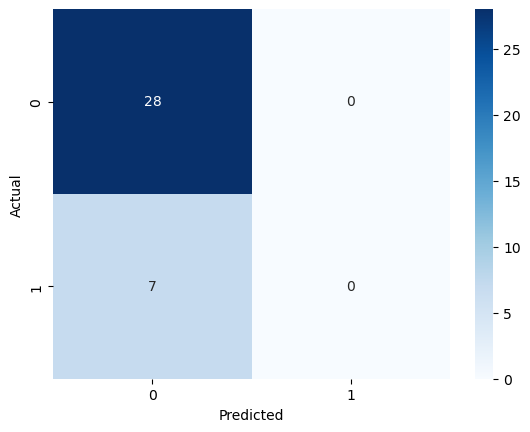

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Checking  Model prefromance by using sentences

In [ ]:
sample = ["love this!"]  

sample_vec = vectorizer.transform(sample)

print("Prediction:", svm.predict(sample_vec))


Prediction: [0]
